# Experimento 1 — Zero-Shot (v2)

**Modelos:** Llama 3.1 8B, Mistral 7B, Qwen 2.5 7B, Gemma 2 9B  
**Estratégia:** Zero-shot (sem exemplos no prompt)  
**Dataset:** ENEM  
**Particionamento:** Stratified K-Fold (5 folds)  
**Métricas:** QWK, F1 Score, MAE, RMSE  

**Correções v2:**
- `apply_chat_template` em todos os modelos
- Prompt mais explícito sobre escala 0-200
- Extrator com detecção e correção de escala errada
- Célula de visualização (tabela + gráfico)

⚠️ **Antes de rodar:** `Ambiente de execução → Alterar tipo → GPU A100`

## Célula 1 — Instalação de bibliotecas

In [1]:
!pip install -q transformers accelerate bitsandbytes gdown scikit-learn matplotlib
print("Bibliotecas instaladas!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.5 MB/s eta 0:00:00
Bibliotecas instaladas!


## Célula 2 — Carregamento e pré-processamento do dataset

In [2]:
import gdown
import pandas as pd
import re

id_do_arquivo = '1zg9n7EUDWKfu6t_f3aYDS_QroYXGNGwd'
url = f'https://drive.google.com/uc?id={id_do_arquivo}'

print("Baixando o dataset...")
gdown.download(url, 'meu_dataset.csv', quiet=False)

df_enem = pd.read_csv('meu_dataset.csv')

def limpar_redacao(texto):
    if pd.isna(texto): return ""
    texto = str(texto)
    texto = texto.strip("[]'\" ")
    texto = texto.replace('\n', ' ')
    texto = re.sub(r'\[[A-Z/]+\]', '', texto)
    texto = re.sub(r'\{[a-z]+\}', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

df_enem['essay_limpo'] = df_enem['essay'].apply(limpar_redacao)
df_enem = df_enem[df_enem['score'] > 0].reset_index(drop=True)

print(f"Dataset carregado: {len(df_enem)} redações válidas")

Baixando o dataset...


Downloading...
From: https://drive.google.com/uc?id=1zg9n7EUDWKfu6t_f3aYDS_QroYXGNGwd
To: /content/meu_dataset.csv
100%|██████████| 13.0M/13.0M [00:00<00:00, 42.5MB/s]


Dataset carregado: 6485 redações válidas


## Célula 3 — Particionamento Stratified K-Fold

In [3]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df_enem['fold'] = -1

for i, (train_index, test_index) in enumerate(skf.split(df_enem, df_enem['score'])):
    df_enem.loc[test_index, 'fold'] = i

print(f"Total: {len(df_enem)} redações")
print(f"\nDistribuição dos folds:")
print(df_enem['fold'].value_counts().sort_index())

Total: 6485 redações

Distribuição dos folds:
fold
0    1297
1    1297
2    1297
3    1297
4    1297
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


## Célula 4 — Prompt Zero-Shot

In [4]:
def gerar_prompt_zero_shot(redacao):
    return f"""Você é um avaliador oficial de redações do ENEM (Exame Nacional do Ensino Médio) do Brasil.

Avalie a redação abaixo seguindo RIGOROSAMENTE a escala oficial do ENEM:
- Cada competência recebe uma nota de 0, 40, 80, 120, 160 ou 200 pontos
- A nota total é a SOMA das 5 competências (máximo 1000 pontos)

COMPETÊNCIAS:
- C1 (Norma Culta): domínio da norma padrão da língua escrita (0-200)
- C2 (Tema/Estrutura): adequação ao tema e à estrutura dissertativo-argumentativa (0-200)
- C3 (Argumentação): seleção e organização de argumentos (0-200)
- C4 (Coesão): uso de mecanismos linguísticos para articulação do texto (0-200)
- C5 (Proposta de Intervenção): proposta detalhada com agente, ação, meio, efeito e detalhamento (0-200)

ATENÇÃO: Use APENAS os valores 0, 40, 80, 120, 160 ou 200 para cada competência.

REDAÇÃO:
{redacao}

Responda APENAS com o JSON abaixo, sem texto adicional:
{{"C1": valor, "C2": valor, "C3": valor, "C4": valor, "C5": valor, "Nota_Total": soma}}"""

df_enem['prompt'] = df_enem['essay_limpo'].apply(gerar_prompt_zero_shot)
print("Prompts gerados!")

Prompts gerados!


## Célula 5 — Funções auxiliares

In [5]:
import torch
import json
import gc
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score, f1_score

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

def carregar_modelo(nome_modelo):
    print(f"\nCarregando {nome_modelo}...")
    tokenizer = AutoTokenizer.from_pretrained(nome_modelo, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        nome_modelo,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    model.eval()
    print(f"Modelo carregado!")
    return tokenizer, model

def liberar_modelo(model, tokenizer):
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("Memória GPU liberada.")

def gerar_resposta(tokenizer, model, prompt, max_new_tokens=300):
    # Usa o chat template correto de cada modelo
    messages = [{"role": "user", "content": prompt}]
    try:
        texto_formatado = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except:
        # Fallback se o modelo não suportar chat template
        texto_formatado = prompt

    inputs = tokenizer(
        texto_formatado,
        return_tensors="pt",
        truncation=True,
        max_length=3072
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    resposta = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return resposta.strip()

def extrair_notas(resposta):
    """Extrai notas do JSON e corrige escala errada automaticamente"""
    try:
        texto = str(resposta)
        # Remove blocos de código markdown se existirem
        texto = re.sub(r'```json|```', '', texto)
        inicio = texto.find('{')
        fim = texto.rfind('}') + 1
        if inicio == -1 or fim <= inicio:
            return None
        dados = json.loads(texto[inicio:fim])

        competencias = ['C1', 'C2', 'C3', 'C4', 'C5']

        # Recalcula Nota_Total se não existir ou estiver errada
        if all(c in dados for c in competencias):
            soma = sum(dados[c] for c in competencias)

            # Detecta escala errada: se a soma máxima possível for <= 100
            # significa que o modelo usou escala 0-20 em vez de 0-200
            max_possivel = max(dados[c] for c in competencias)
            if max_possivel <= 20:
                # Multiplica por 10 para converter para escala 0-200
                for c in competencias:
                    dados[c] = dados[c] * 10
                soma = sum(dados[c] for c in competencias)

            dados['Nota_Total'] = soma
            return dados

        if 'Nota_Total' in dados:
            return dados

    except:
        pass
    return None

def calcular_metricas(y_true, y_pred, nome_modelo):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    def discretizar(notas):
        return np.clip(np.round(np.array(notas) / 40).astype(int), 0, 25)

    y_true_d = discretizar(y_true)
    y_pred_d = discretizar(y_pred)

    try:
        qwk = cohen_kappa_score(y_true_d, y_pred_d, weights='quadratic')
    except:
        qwk = float('nan')
    try:
        f1 = f1_score(y_true_d, y_pred_d, average='weighted', zero_division=0)
    except:
        f1 = float('nan')

    print(f"\n{'='*50}")
    print(f"MÉTRICAS — {nome_modelo}")
    print(f"{'='*50}")
    print(f"  Amostras: {len(y_true)}")
    print(f"  MAE:      {mae:.4f}")
    print(f"  RMSE:     {rmse:.4f}")
    print(f"  QWK:      {qwk:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"{'='*50}")

    return {'modelo': nome_modelo, 'mae': mae, 'rmse': rmse, 'qwk': qwk, 'f1': f1, 'n': len(y_true)}

print("Funções auxiliares carregadas!")

Funções auxiliares carregadas!


## Célula 6 — Função principal de execução

In [6]:
def rodar_modelo(nome_modelo, coluna_resposta, fold=0, n_amostras=50):
    if coluna_resposta not in df_enem.columns:
        df_enem[coluna_resposta] = None

    df_pendente = df_enem[
        (df_enem['fold'] == fold) &
        (df_enem[coluna_resposta].isna())
    ]
    if n_amostras:
        df_pendente = df_pendente.head(n_amostras)

    print(f"\nModelo: {nome_modelo}")
    print(f"Fold: {fold} | Redações a processar: {len(df_pendente)}")

    if len(df_pendente) == 0:
        print("Nenhuma redação pendente!")
        return

    tokenizer, model = carregar_modelo(nome_modelo)

    erros = 0
    for idx, (index, row) in enumerate(df_pendente.iterrows()):
        try:
            resposta = gerar_resposta(tokenizer, model, row['prompt'])
            df_enem.at[index, coluna_resposta] = resposta
            if (idx + 1) % 10 == 0:
                print(f"  Processadas: {idx+1}/{len(df_pendente)}")
        except Exception as e:
            print(f"  Erro na redação {index}: {e}")
            erros += 1
            if erros >= 3:
                print("  3 erros seguidos — interrompendo.")
                break

    liberar_modelo(model, tokenizer)
    df_enem.to_csv(f'progresso_exp1_{coluna_resposta}.csv', index=False)
    print(f"Progresso salvo!")

print("Função de execução carregada!")

Função de execução carregada!


## Célula 7 — Modelo 1: Llama 3.1 8B
⚠️ Aceite os termos em: https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct

In [7]:
rodar_modelo(
    nome_modelo="meta-llama/Llama-3.1-8B-Instruct",
    coluna_resposta="resposta_llama",
    fold=0,
    n_amostras=50
)


Modelo: meta-llama/Llama-3.1-8B-Instruct
Fold: 0 | Redações a processar: 50

Carregando meta-llama/Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Modelo carregado!
  Processadas: 10/50
  Processadas: 20/50
  Processadas: 30/50
  Processadas: 40/50
  Processadas: 50/50
Memória GPU liberada.
Progresso salvo!


## Célula 8 — Modelo 2: Mistral 7B
⚠️ Aceite os termos em: https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3

In [8]:
rodar_modelo(
    nome_modelo="mistralai/Mistral-7B-Instruct-v0.3",
    coluna_resposta="resposta_mistral",
    fold=0,
    n_amostras=50
)


Modelo: mistralai/Mistral-7B-Instruct-v0.3
Fold: 0 | Redações a processar: 50

Carregando mistralai/Mistral-7B-Instruct-v0.3...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Modelo carregado!
  Processadas: 10/50
  Processadas: 20/50
  Processadas: 30/50
  Processadas: 40/50
  Processadas: 50/50
Memória GPU liberada.
Progresso salvo!


## Célula 9 — Modelo 3: Qwen 2.5 7B

In [9]:
rodar_modelo(
    nome_modelo="Qwen/Qwen2.5-7B-Instruct",
    coluna_resposta="resposta_qwen",
    fold=0,
    n_amostras=50
)


Modelo: Qwen/Qwen2.5-7B-Instruct
Fold: 0 | Redações a processar: 50

Carregando Qwen/Qwen2.5-7B-Instruct...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Modelo carregado!
  Processadas: 10/50
  Processadas: 20/50
  Processadas: 30/50
  Processadas: 40/50
  Processadas: 50/50
Memória GPU liberada.
Progresso salvo!


## Célula 10 — Modelo 4: Gemma 2 9B
⚠️ Aceite os termos em: https://huggingface.co/google/gemma-2-9b-it

In [10]:
rodar_modelo(
    nome_modelo="google/gemma-2-9b-it",
    coluna_resposta="resposta_gemma2",
    fold=0,
    n_amostras=50
)


Modelo: google/gemma-2-9b-it
Fold: 0 | Redações a processar: 50

Carregando google/gemma-2-9b-it...


config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Modelo carregado!
  Processadas: 10/50
  Processadas: 20/50
  Processadas: 30/50
  Processadas: 40/50
  Processadas: 50/50
Memória GPU liberada.
Progresso salvo!


## Célula 11 — Cálculo de métricas

In [11]:
resultados_exp1 = []

modelos = {
    'Llama 3.1 8B':  'resposta_llama',
    'Mistral 7B':    'resposta_mistral',
    'Qwen 2.5 7B':   'resposta_qwen',
    'Gemma 2 9B':    'resposta_gemma2',
}

print("╔══════════════════════════════════════════════╗")
print("║   RESULTADOS — EXPERIMENTO 1 (ZERO-SHOT)    ║")
print("╚══════════════════════════════════════════════╝")

for nome, col in modelos.items():
    if col not in df_enem.columns:
        print(f"\n{nome}: sem respostas ainda")
        continue
    df_modelo = df_enem[df_enem[col].notna()].copy()
    if len(df_modelo) == 0:
        print(f"\n{nome}: sem respostas ainda")
        continue
    df_modelo['pred_total'] = df_modelo[col].apply(
        lambda r: extrair_notas(r).get('Nota_Total') if extrair_notas(r) else None
    )
    df_modelo = df_modelo.dropna(subset=['pred_total'])
    if len(df_modelo) == 0:
        print(f"\n{nome}: respostas inválidas")
        continue
    resultado = calcular_metricas(
        df_modelo['score'].tolist(),
        df_modelo['pred_total'].tolist(),
        nome
    )
    resultados_exp1.append(resultado)

if resultados_exp1:
    df_resultados = pd.DataFrame(resultados_exp1)
    df_resultados.to_csv('resultados_exp1_zero_shot.csv', index=False)
    print("\nResultados salvos!")

╔══════════════════════════════════════════════╗
║   RESULTADOS — EXPERIMENTO 1 (ZERO-SHOT)    ║
╚══════════════════════════════════════════════╝

MÉTRICAS — Llama 3.1 8B
  Amostras: 50
  MAE:      160.8000
  RMSE:     195.7141
  QWK:      0.1825
  F1 Score: 0.1817

MÉTRICAS — Mistral 7B
  Amostras: 50
  MAE:      320.0000
  RMSE:     337.5204
  QWK:      0.0064
  F1 Score: 0.0000

MÉTRICAS — Qwen 2.5 7B
  Amostras: 50
  MAE:      189.6000
  RMSE:     222.3511
  QWK:      0.0459
  F1 Score: 0.1067

MÉTRICAS — Gemma 2 9B
  Amostras: 50
  MAE:      122.4000
  RMSE:     142.9405
  QWK:      -0.0210
  F1 Score: 0.0641

Resultados salvos!


## Célula 12 — Visualização: Tabela + Gráfico


Modelo                    N      MAE     RMSE      QWK       F1
-----------------------------------------------------------------
Llama 3.1 8B             50 160.8000 195.7141   0.1825   0.1817
Mistral 7B               50 320.0000 337.5204   0.0064   0.0000
Qwen 2.5 7B              50 189.6000 222.3511   0.0459   0.1067
Gemma 2 9B               50 122.4000 142.9405  -0.0210   0.0641


/tmp/ipykernel_15056/259027763.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)
/tmp/ipykernel_15056/259027763.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)
/tmp/ipykernel_15056/259027763.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)
/tmp/ipykernel_15056/259027763.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)


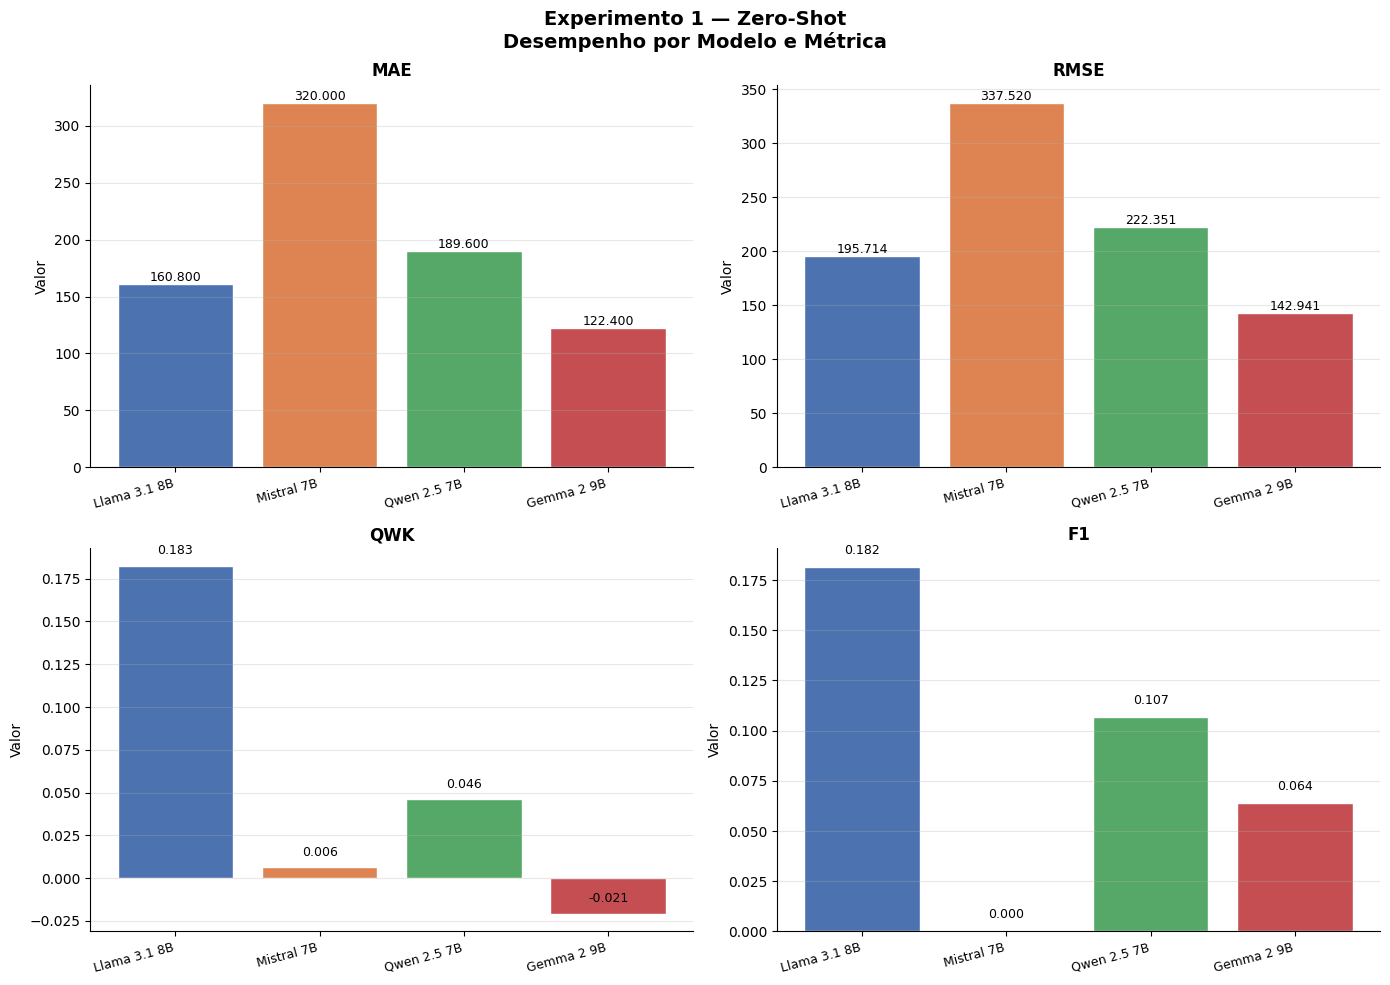

Gráfico salvo em grafico_exp1_zero_shot.png


In [12]:
import matplotlib.pyplot as plt

df_plot = pd.DataFrame(resultados_exp1)

# ── Tabela formatada ────────────────────────────────────────────
print("\n" + "="*65)
print(f"{'Modelo':<20} {'N':>6} {'MAE':>8} {'RMSE':>8} {'QWK':>8} {'F1':>8}")
print("-"*65)
for _, row in df_plot.iterrows():
    print(f"{row['modelo']:<20} {int(row['n']):>6} {row['mae']:>8.4f} {row['rmse']:>8.4f} {row['qwk']:>8.4f} {row['f1']:>8.4f}")
print("="*65)

# ── Gráfico de barras ───────────────────────────────────────────
metricas = ['MAE', 'RMSE', 'QWK', 'F1']
colunas  = ['mae', 'rmse', 'qwk', 'f1']
cores    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experimento 1 — Zero-Shot\nDesempenho por Modelo e Métrica',
             fontsize=14, fontweight='bold')

for ax, metrica, coluna in zip(axes.flatten(), metricas, colunas):
    valores = df_plot[coluna].tolist()
    nomes   = df_plot['modelo'].tolist()
    barras  = ax.bar(nomes, valores, color=cores, edgecolor='white')
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2,
                barra.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticklabels(nomes, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grafico_exp1_zero_shot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em grafico_exp1_zero_shot.png")

## Célula 13 — Salvar CSV final

In [13]:
df_enem.to_csv('exp1_zero_shot_completo.csv', index=False)
print("CSV final salvo em exp1_zero_shot_completo.csv")
print(f"\nResumo:")
for nome, col in modelos.items():
    if col in df_enem.columns:
        n = df_enem[col].notna().sum()
        status = '✅' if n >= 50 else '⚠️'
        print(f"  {status} {nome}: {n} respostas")

CSV final salvo em exp1_zero_shot_completo.csv

Resumo:
  ✅ Llama 3.1 8B: 50 respostas
  ✅ Mistral 7B: 50 respostas
  ✅ Qwen 2.5 7B: 50 respostas
  ✅ Gemma 2 9B: 50 respostas
